In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Allow importing eval.metrics from the scripts/ directory
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from eval.metrics import read_traj_metrics  # available for instance-level analysis

In [2]:
# ── Evaluation directories ────────────────────────────────────────────────────
# Set EVAL_DIR_B = None  → single-eval report for EVAL_DIR_A only.
# Set EVAL_DIR_B to a path → side-by-side comparison (A = original, B = metamorphic).

# usually, original
EVAL_DIR_A = "/Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/results/eval_3_easy_benchmarks"
# usually, metamorphic
EVAL_DIR_B = EVAL_DIR_A   # change to None or another path

LABEL_A = "Original"
LABEL_B = "Metamorphic"

# ── Plot styling ──────────────────────────────────────────────────────────────
COLOR_A    = "#4C72B0"   # blue  — eval A
COLOR_B    = "#DD8452"   # orange — eval B
ALPHA_BAND = 0.15        # opacity of ±std shaded bands

plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "axes.titlesize":    11,
    "axes.labelsize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
})

print(f"Mode: {'comparison' if EVAL_DIR_B is not None else 'single'}")
print(f"  A = {Path(EVAL_DIR_A).name!r}  ({LABEL_A})")
if EVAL_DIR_B is not None:
    print(f"  B = {Path(EVAL_DIR_B).name!r}  ({LABEL_B})")

Mode: comparison
  A = 'eval_3_easy_benchmarks'  (Original)
  B = 'eval_3_easy_benchmarks'  (Metamorphic)


In [3]:
# ─── Data loading ─────────────────────────────────────────────────────────────

def load_metrics(dirpath, filename: str = "metrics_summary.json") -> dict:
    """Load metrics_summary.json from an eval results directory."""
    path = Path(dirpath) / filename
    if not path.exists():
        raise FileNotFoundError(f"metrics_summary.json not found in: {dirpath}")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_instance_observations(dirpath) -> dict:
    """
    Walk eval_dir/run-*/result.json and collect per-instance agent metrics.

    Returns a dict of field → list (one entry per instance across all runs):
        instance_cost, api_calls, tokens_sent, tokens_received, tokens_total

    Runs with a missing or empty execution list are silently skipped.
    """
    obs = {f: [] for f in ("instance_cost", "api_calls",
                            "tokens_sent", "tokens_received", "tokens_total")}
    for path in sorted(Path(dirpath).glob("run-*/result.json")):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        for inst in data.get("agent", {}).get("metrics", {}).get("execution", []):
            for field in ("instance_cost", "api_calls", "tokens_sent", "tokens_received"):
                if field in inst:
                    obs[field].append(inst[field])
            sent = inst.get("tokens_sent")
            recv = inst.get("tokens_received")
            if sent is not None and recv is not None:
                obs["tokens_total"].append(sent + recv)
    return obs


def validate_metrics(metrics: dict, label: str) -> list:
    """
    Return a list of warning strings for data quality issues:
    - Runs where total_instances < n_instances_per_run (incomplete eval run, pass rate may be inflated)
    - Runs with n_missing > 0 in agent metrics (missing .traj files)
    """
    issues = []
    expected = metrics.get("n_instances_per_run")

    for run in metrics.get("per_run", []):
        run_num = run["run_number"]
        ev = run.get("evaluation")
        if ev and expected is not None and ev["total_instances"] < expected:
            issues.append(
                f"[{label}] Run {run_num}: only {ev['total_instances']} of "
                f"{expected} instances were evaluated — pass rate may be inflated."
            )
        ag = run.get("agent")
        if ag and ag.get("n_missing", 0) > 0:
            issues.append(
                f"[{label}] Run {run_num}: {ag['n_missing']} trajectory file(s) missing "
                "— agent metrics are incomplete."
            )
    return issues


def get_per_run_pass_rates(metrics: dict) -> list:
    """Extract per_run[i].evaluation.pass_rate values in run order."""
    return [
        run["evaluation"]["pass_rate"]
        for run in metrics["per_run"]
        if run.get("evaluation") is not None
    ]


def get_per_run_agent_field(metrics: dict, field: str) -> list:
    """Extract per_run[i].agent.{field}.avg values in run order."""
    return [
        run["agent"][field]["avg"]
        for run in metrics["per_run"]
        if run.get("agent") and field in run["agent"]
    ]


def get_per_run_tokens_total(metrics: dict) -> list:
    """
    Return per-run total token counts (tokens_sent + tokens_received) derived
    from per_run data.  tokens_total is not stored in metrics_summary.json; it
    is computed here for plotting purposes.
    """
    result = []
    for run in metrics["per_run"]:
        ag       = run.get("agent", {})
        sent     = ag.get("tokens_sent",     {}).get("avg")
        received = ag.get("tokens_received", {}).get("avg")
        if sent is not None and received is not None:
            result.append(sent + received)
    return result


def get_run_numbers(metrics: dict) -> list:
    """Return the run_number list from per_run."""
    return [r["run_number"] for r in metrics["per_run"]]

In [4]:
# ─── Single-eval plots ────────────────────────────────────────────────────────

def plot_pass_rate_distribution(
    metrics: dict,
    label: str,
    color: str = COLOR_A,
    ax=None,
) -> None:
    """
    Bar chart of per-run pass rates with avg ± std band.
    Anomalous runs (total_instances < n_instances_per_run) are marked with '*'.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 3.5))

    expected   = metrics.get("n_instances_per_run")
    pr         = metrics.get("pass_rate", {})
    avg        = pr.get("avg")
    std        = pr.get("std")
    per_run    = pr.get("per_run", [])
    run_nums   = [r["run_number"] for r in per_run]
    pass_rates = [r["pass_rate"]  for r in per_run]
    totals     = [r["total"]      for r in per_run]

    xs = np.arange(len(run_nums))
    ax.bar(xs, pass_rates, color=color, alpha=0.75, width=0.6, zorder=3)

    for i, (rate, total) in enumerate(zip(pass_rates, totals)):
        if expected is not None and total < expected:
            ax.text(xs[i], rate + 1.5, "*", ha="center", color="crimson", fontsize=13, zorder=5)

    if avg is not None:
        ax.axhline(avg, color=color, linewidth=1.5, linestyle="--", label=f"avg = {avg:.1f}%")
    if avg is not None and std is not None:
        ax.axhspan(avg - std, avg + std, color=color, alpha=ALPHA_BAND, label=f"±std ({std:.1f}%)")

    ax.set_xticks(xs)
    ax.set_xticklabels([f"R{n}" for n in run_nums])
    ax.set_ylim(0, 110)
    ax.set_ylabel("Pass rate (%)")
    ax.set_title(f"{label} — pass rate per run")
    ax.legend(fontsize=8)

    n_inst = metrics.get("n_instances_per_run", "?")
    ax.text(0.01, 0.97, f"M = {n_inst} instances/run  |  * = incomplete eval run",
            transform=ax.transAxes, va="top", fontsize=7, color="gray")


def _plot_field_line(ax, xs, values, avg_val, std_val, color, title):
    """Internal helper: draw a single per-run line with avg ± std band."""
    ax.plot(xs, values, marker="o", color=color, linewidth=1.5, markersize=5, zorder=3)
    if avg_val is not None:
        ax.axhline(avg_val, color=color, linestyle="--", linewidth=1, alpha=0.6)
    if avg_val is not None and std_val is not None:
        ax.axhspan(avg_val - std_val, avg_val + std_val, color=color, alpha=ALPHA_BAND)
    ax.set_title(title)


def plot_agent_cost_api_per_run(
    metrics: dict,
    label: str,
    color: str = COLOR_A,
) -> None:
    """
    1×2 subplot: per-run line charts for instance_cost and api_calls.

    instance_cost (not total_cost) is the primary cost metric: it is the
    marginal cost for a single instance's API calls, independent of session
    ordering.  total_cost accumulates context across multiple instances in the
    same session and is not comparable across different session sizes.
    """
    fields = ("instance_cost", "api_calls")
    titles = ("Instance cost (USD)", "API calls")

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    fig.suptitle(f"{label} — cost & API calls per run", fontsize=11, y=1.02)

    run_nums = get_run_numbers(metrics)
    var      = metrics.get("run_variability", {})
    xs       = np.arange(len(run_nums))

    for ax, field, title in zip(axes, fields, titles):
        values  = get_per_run_agent_field(metrics, field)
        fv      = var.get(field, {})
        _plot_field_line(ax, xs, values, fv.get("avg_of_run_avgs"), fv.get("std_of_run_avgs"),
                         color, title)
        ax.set_xticks(xs)
        ax.set_xticklabels([f"R{n}" for n in run_nums])

    plt.tight_layout()


def plot_agent_tokens_per_run(
    metrics: dict,
    label: str,
    color: str = COLOR_A,
) -> None:
    """
    1×3 subplot: per-run line charts for tokens_sent, tokens_received, and
    tokens_total (= sent + received, derived — not stored in the JSON).

    Shaded band shows ±std_of_run_avgs for stored fields; for tokens_total
    the band is derived from the per-run totals using numpy.
    """
    run_nums      = get_run_numbers(metrics)
    var           = metrics.get("run_variability", {})
    xs            = np.arange(len(run_nums))
    tokens_total  = get_per_run_tokens_total(metrics)

    # Derive avg and std for tokens_total from per-run values
    total_avg = float(np.mean(tokens_total)) if tokens_total else None
    total_std = float(np.std(tokens_total, ddof=1)) if len(tokens_total) >= 2 else None

    FIELDS = [
        ("tokens_sent",     "Tokens sent",     get_per_run_agent_field(metrics, "tokens_sent"),
         var.get("tokens_sent", {}).get("avg_of_run_avgs"),
         var.get("tokens_sent", {}).get("std_of_run_avgs")),
        ("tokens_received", "Tokens received", get_per_run_agent_field(metrics, "tokens_received"),
         var.get("tokens_received", {}).get("avg_of_run_avgs"),
         var.get("tokens_received", {}).get("std_of_run_avgs")),
        ("tokens_total",    "Tokens total",    tokens_total,
         total_avg, total_std),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    fig.suptitle(f"{label} — tokens per run", fontsize=11, y=1.02)

    for ax, (_, title, values, avg_val, std_val) in zip(axes, FIELDS):
        _plot_field_line(ax, xs, values, avg_val, std_val, color, title)
        ax.set_xticks(xs)
        ax.set_xticklabels([f"R{n}" for n in run_nums])

    plt.tight_layout()


def _draw_single_boxplot(ax, data, color, ylabel, title, value_fmt=".3f"):
    """
    Single-group boxplot over pooled per-instance observations.

    Box spans Q1–Q3; red solid line = median; blue dashed line = mean.
    Whiskers extend to the most extreme non-outlier values (1.5×IQR).
    """
    bp = ax.boxplot(
        [data], positions=[1], widths=0.45,
        patch_artist=True,
        showmeans=True, meanline=True,
        meanprops=dict(color="blue", linewidth=2, linestyle="--"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="D", markerfacecolor="gray",
                        markeredgecolor="none", markersize=5, alpha=0.7),
    )
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.65)

    median     = float(np.median(data))
    mean       = float(np.mean(data))
    q3         = float(np.percentile(data, 75))
    data_range = max(data) - min(data) if len(data) > 1 else 1
    ax.text(1, q3 + data_range * 0.08,
            f"med {median:{value_fmt}}\navg {mean:{value_fmt}}",
            ha="center", fontsize=7, linespacing=1.5,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

    ax.set_xticks([])
    ax.set_ylabel(ylabel)
    ax.set_title(title)


def plot_pooled_cost_api_single(
    obs: dict,
    label: str,
    color: str = COLOR_A,
) -> None:
    """
    1×2 figure of pooled per-instance boxplots for instance_cost and api_calls.
    Each box is built from N_runs × M_instances individual observations.
    """
    n = len(obs.get("instance_cost", []))
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    fig.suptitle(f"{label} — pooled instance cost & API calls ({n} observations)", fontsize=11)

    _draw_single_boxplot(axes[0], obs["instance_cost"], color,
                         "Instance cost (USD)", "Instance cost (USD)", value_fmt=".4f")
    _draw_single_boxplot(axes[1], obs["api_calls"], color,
                         "API calls", "API calls", value_fmt=".1f")
    plt.tight_layout()


def plot_pooled_tokens_single(
    obs: dict,
    label: str,
    color: str = COLOR_A,
) -> None:
    """
    1×3 figure of pooled per-instance boxplots for tokens_sent, tokens_received,
    and tokens_total (= sent + received, derived).
    Each box is built from N_runs × M_instances individual observations.
    """
    n = len(obs.get("tokens_sent", []))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig.suptitle(f"{label} — pooled token usage ({n} observations)", fontsize=11)

    _draw_single_boxplot(axes[0], obs["tokens_sent"],     color,
                         "Tokens sent",     "Tokens sent",     value_fmt=",.0f")
    _draw_single_boxplot(axes[1], obs["tokens_received"], color,
                         "Tokens received", "Tokens received", value_fmt=",.0f")
    _draw_single_boxplot(axes[2], obs["tokens_total"],    color,
                         "Tokens total",    "Tokens total",    value_fmt=",.0f")
    plt.tight_layout()


def plot_cost_vs_tokens_scatter(metrics: dict, label: str, color: str = COLOR_A, ax=None) -> None:
    """
    Scatter: avg tokens_sent vs avg instance_cost per run, annotated with run numbers.
    Useful for confirming linear cost scaling and spotting outlier (expensive/stuck) runs.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    run_nums = get_run_numbers(metrics)
    costs    = get_per_run_agent_field(metrics, "instance_cost")
    tokens   = get_per_run_agent_field(metrics, "tokens_sent")

    ax.scatter(tokens, costs, color=color, s=60, zorder=3, alpha=0.85)
    for rn, x, y in zip(run_nums, tokens, costs):
        ax.annotate(f"R{rn}", (x, y), textcoords="offset points",
                    xytext=(5, 3), fontsize=7, color="gray")

    ax.set_xlabel("Avg tokens sent")
    ax.set_ylabel("Avg instance cost (USD)")
    ax.set_title(f"{label} — cost vs. tokens per run")


def print_summary_table(metrics: dict, label: str) -> None:
    """Print headline numbers as a formatted text summary."""
    pr   = metrics.get("pass_rate", {})
    pool = metrics.get("pooled", {})
    n_r  = metrics.get("n_runs", "?")
    n_i  = metrics.get("n_instances_per_run", "?")

    avg_pr = pr.get("avg")
    std_pr = pr.get("std")
    ic     = pool.get("instance_cost", {})
    ts     = pool.get("tokens_sent", {})
    tr     = pool.get("tokens_received", {})
    ac     = pool.get("api_calls", {})

    ts_avg = ts.get("avg")
    tr_avg = tr.get("avg")

    print(f"{'─'*50}")
    print(f"  {label}  ({n_r} runs × {n_i} instances)")
    print(f"{'─'*50}")
    if avg_pr is not None:
        std_s = f"± {std_pr:.1f}" if std_pr is not None else ""
        print(f"  Pass rate        {avg_pr:>6.1f} %   {std_s}")
    if ic.get("avg") is not None:
        print(f"  Instance cost    ${ic['avg']:>8.4f}   (median ${ic['median']:.4f})")
    if ts_avg is not None:
        print(f"  Tokens sent      {ts_avg:>10,.0f}   (median {ts['median']:,.0f})")
    if tr_avg is not None:
        print(f"  Tokens received  {tr_avg:>10,.0f}   (median {tr['median']:,.0f})")
    if ts_avg is not None and tr_avg is not None:
        print(f"  Tokens total     {ts_avg + tr_avg:>10,.0f}")
    if ac.get("avg") is not None:
        print(f"  API calls        {ac['avg']:>7.1f}   (median {ac['median']:.1f})")
    print(f"{'─'*50}")

    if isinstance(n_i, int) and n_i <= 5:
        print(f"\n  Note: M={n_i} instances/run → pass rate takes only discrete values")
        print(f"  (multiples of {100/n_i:.1f}%). The ±std reflects discrete distribution")
        print(f"  spread, not measurement noise.")

In [5]:
# ─── Comparison plots (A vs B) ────────────────────────────────────────────────

def plot_pass_rate_comparison(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
    ax=None,
) -> None:
    """
    Box plot comparing per-run pass rates for A and B.
    Each box is built from N per-run pass rate values (one per run).
    The internal red line is the median; the blue dashed line is the mean.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.5))

    rates_a = get_per_run_pass_rates(metrics_a)
    rates_b = get_per_run_pass_rates(metrics_b)
    _draw_boxplot(ax, rates_a, rates_b, label_a, label_b,
                  "Pass rate (%)", "Pass rate comparison", value_fmt=".1f")
    ax.set_ylim(-5, 110)


def plot_pass_rate_per_run_overlay(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
    ax=None,
) -> None:
    """
    Two lines on the same axes: per-run pass rates for A and B.
    Shows run-to-run shape rather than just summary stats.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    rates_a = get_per_run_pass_rates(metrics_a)
    rates_b = get_per_run_pass_rates(metrics_b)
    n = max(len(rates_a), len(rates_b))
    xs = np.arange(1, n + 1)

    if rates_a:
        ax.plot(xs[:len(rates_a)], rates_a, marker="o", color=COLOR_A,
                linewidth=1.5, markersize=5, label=label_a)
    if rates_b:
        ax.plot(xs[:len(rates_b)], rates_b, marker="s", color=COLOR_B,
                linewidth=1.5, markersize=5, linestyle="--", label=label_b)

    ax.set_xlabel("Run number")
    ax.set_ylabel("Pass rate (%)")
    ax.set_ylim(-5, 110)
    ax.set_xticks(xs)
    ax.set_title("Per-run pass rates")
    ax.legend(fontsize=8)


# ── Box plot helpers ──────────────────────────────────────────────────────────

def _draw_boxplot(ax, data_a, data_b, label_a, label_b, ylabel, title, value_fmt=".3f"):
    """
    Draw side-by-side box plots for two groups (A and B).

    Box layout:
      - Box spans Q1 (25th pct) to Q3 (75th pct)
      - Red solid line inside box = median (50th pct)
      - Blue dashed line = mean
      - Whiskers extend to min/max within 1.5×IQR; points beyond are outliers

    Annotations above each box show exact median and mean values.
    """
    positions = [1, 2]
    bp = ax.boxplot(
        [data_a, data_b],
        positions=positions,
        widths=0.45,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        meanprops=dict(color="blue", linewidth=2, linestyle="--"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="D", markerfacecolor="gray",
                        markeredgecolor="none", markersize=5, alpha=0.7),
    )

    for patch, color in zip(bp["boxes"], [COLOR_A, COLOR_B]):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    # Annotate median and mean above each box
    all_data = list(data_a) + list(data_b)
    data_range = max(all_data) - min(all_data) if len(all_data) > 1 else 1
    for data, pos in zip([data_a, data_b], positions):
        q3     = float(np.percentile(data, 75))
        median = float(np.median(data))
        mean   = float(np.mean(data))
        yoff   = q3 + data_range * 0.08
        ax.text(pos, yoff,
                f"med {median:{value_fmt}}\navg {mean:{value_fmt}}",
                ha="center", fontsize=7, linespacing=1.5,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

    ax.set_xticks(positions)
    ax.set_xticklabels([label_a, label_b])
    ax.set_ylabel(ylabel)
    ax.set_title(title)


def plot_agent_cost_api_comparison(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    1×2 box plot figure comparing instance_cost and api_calls for A vs B.

    Each box is built from N per-run averages (one data point per run).
    The box spans Q1–Q3; the red line is the median; the blue dashed line is the mean.
    Whiskers reach the most extreme non-outlier values (within 1.5×IQR).
    """
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    fig.suptitle("Cost & API calls comparison (per-run averages)", fontsize=11)

    cost_a = get_per_run_agent_field(metrics_a, "instance_cost")
    cost_b = get_per_run_agent_field(metrics_b, "instance_cost")
    _draw_boxplot(axes[0], cost_a, cost_b, label_a, label_b,
                  "Instance cost (USD)", "Instance cost (USD)", value_fmt=".4f")

    api_a = get_per_run_agent_field(metrics_a, "api_calls")
    api_b = get_per_run_agent_field(metrics_b, "api_calls")
    _draw_boxplot(axes[1], api_a, api_b, label_a, label_b,
                  "API calls", "API calls", value_fmt=".1f")

    plt.tight_layout()


def plot_tokens_comparison(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    1×3 box plot figure comparing tokens_sent, tokens_received, and tokens_total
    (= sent + received, derived) for A vs B.

    Each box is built from N per-run averages.
    """
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig.suptitle("Token usage comparison (per-run averages)", fontsize=11)

    sent_a = get_per_run_agent_field(metrics_a, "tokens_sent")
    sent_b = get_per_run_agent_field(metrics_b, "tokens_sent")
    _draw_boxplot(axes[0], sent_a, sent_b, label_a, label_b,
                  "Tokens sent", "Tokens sent", value_fmt=",.0f")

    recv_a = get_per_run_agent_field(metrics_a, "tokens_received")
    recv_b = get_per_run_agent_field(metrics_b, "tokens_received")
    _draw_boxplot(axes[1], recv_a, recv_b, label_a, label_b,
                  "Tokens received", "Tokens received", value_fmt=",.0f")

    total_a = get_per_run_tokens_total(metrics_a)
    total_b = get_per_run_tokens_total(metrics_b)
    _draw_boxplot(axes[2], total_a, total_b, label_a, label_b,
                  "Tokens total", "Tokens total", value_fmt=",.0f")

    plt.tight_layout()


def plot_pooled_cost_api_comparison(
    obs_a: dict, obs_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    1×2 box plot figure comparing pooled per-instance instance_cost and api_calls
    for A vs B. Each box is built from N_runs × M_instances individual observations.
    """
    n_a = len(obs_a.get("instance_cost", []))
    n_b = len(obs_b.get("instance_cost", []))
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    fig.suptitle(
        f"Pooled cost & API calls comparison  ({label_a}: {n_a} obs, {label_b}: {n_b} obs)",
        fontsize=11,
    )

    _draw_boxplot(axes[0], obs_a["instance_cost"], obs_b["instance_cost"],
                  label_a, label_b, "Instance cost (USD)", "Instance cost (USD)", value_fmt=".4f")
    _draw_boxplot(axes[1], obs_a["api_calls"], obs_b["api_calls"],
                  label_a, label_b, "API calls", "API calls", value_fmt=".1f")
    plt.tight_layout()


def plot_pooled_tokens_comparison(
    obs_a: dict, obs_b: dict,
    label_a: str, label_b: str,
) -> None:
    """
    1×3 box plot figure comparing pooled per-instance token metrics for A vs B.
    Each box is built from N_runs × M_instances individual observations.
    """
    n_a = len(obs_a.get("tokens_sent", []))
    n_b = len(obs_b.get("tokens_sent", []))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    fig.suptitle(
        f"Pooled token usage comparison  ({label_a}: {n_a} obs, {label_b}: {n_b} obs)",
        fontsize=11,
    )

    _draw_boxplot(axes[0], obs_a["tokens_sent"],     obs_b["tokens_sent"],
                  label_a, label_b, "Tokens sent",     "Tokens sent",     value_fmt=",.0f")
    _draw_boxplot(axes[1], obs_a["tokens_received"], obs_b["tokens_received"],
                  label_a, label_b, "Tokens received", "Tokens received", value_fmt=",.0f")
    _draw_boxplot(axes[2], obs_a["tokens_total"],    obs_b["tokens_total"],
                  label_a, label_b, "Tokens total",    "Tokens total",    value_fmt=",.0f")
    plt.tight_layout()

In [6]:
# ─── Dashboard orchestrators ──────────────────────────────────────────────────

def build_single_report(dirpath_a, label_a: str) -> None:
    """
    Full single-eval dashboard.

    Layout:
      Figure 1 — pass rate per run (full width bar chart)
      Figure 2 — instance_cost | api_calls per run (2-col line chart)
      Figure 3 — tokens_sent | tokens_received | tokens_total per run (3-col line chart)
      Figure 4 — pooled instance_cost | api_calls boxplot (2 cols, N×M observations)
      Figure 5 — pooled tokens_sent | tokens_received | tokens_total boxplot (3 cols)
      Figure 6 — cost vs. tokens scatter (per-run averages)
      Text     — headline summary table
    """
    metrics = load_metrics(dirpath_a)

    for w in validate_metrics(metrics, label_a):
        warnings.warn(w, stacklevel=2)

    fig1, ax1 = plt.subplots(figsize=(11, 3.5))
    plot_pass_rate_distribution(metrics, label_a, ax=ax1)
    plt.tight_layout()
    plt.show()

    plot_agent_cost_api_per_run(metrics, label_a)
    plt.show()

    plot_agent_tokens_per_run(metrics, label_a)
    plt.show()

    obs = load_instance_observations(dirpath_a)
    plot_pooled_cost_api_single(obs, label_a)
    plt.show()

    plot_pooled_tokens_single(obs, label_a)
    plt.show()

    fig6, ax6 = plt.subplots(figsize=(5, 4))
    plot_cost_vs_tokens_scatter(metrics, label_a, ax=ax6)
    plt.tight_layout()
    plt.show()

    print()
    print_summary_table(metrics, label_a)


def build_comparison_report(
    dirpath_a, label_a: str,
    dirpath_b, label_b: str,
) -> None:
    """
    Full A-vs-B comparison dashboard.

    Layout:
      Figure 1 — pass rate comparison boxplot | per-run pass rate overlay (2 cols)
      Figure 2 — instance_cost | api_calls comparison (per-run averages, 2-col boxplot)
      Figure 3 — tokens comparison (per-run averages, 3-col boxplot)
      Figure 4 — pooled instance_cost | api_calls comparison (N×M obs, 2-col boxplot)
      Figure 5 — pooled token usage comparison (N×M obs, 3-col boxplot)
      Text     — headline summary tables for both A and B
    """
    metrics_a = load_metrics(dirpath_a)
    metrics_b = load_metrics(dirpath_b)

    for w in validate_metrics(metrics_a, label_a) + validate_metrics(metrics_b, label_b):
        warnings.warn(w, stacklevel=2)

    # Figure 1: pass rate
    fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(12, 4))
    plot_pass_rate_comparison(metrics_a, metrics_b, label_a, label_b, ax=ax1a)
    plot_pass_rate_per_run_overlay(metrics_a, metrics_b, label_a, label_b, ax=ax1b)
    plt.tight_layout()
    plt.show()

    # Figure 2: cost & API calls (per-run averages)
    plot_agent_cost_api_comparison(metrics_a, metrics_b, label_a, label_b)
    plt.show()

    # Figure 3: token usage (per-run averages)
    plot_tokens_comparison(metrics_a, metrics_b, label_a, label_b)
    plt.show()

    # Figure 4: pooled cost & API calls (per-instance observations)
    obs_a = load_instance_observations(dirpath_a)
    obs_b = load_instance_observations(dirpath_b)
    plot_pooled_cost_api_comparison(obs_a, obs_b, label_a, label_b)
    plt.show()

    # Figure 5: pooled token usage (per-instance observations)
    plot_pooled_tokens_comparison(obs_a, obs_b, label_a, label_b)
    plt.show()

    # Summary tables
    print()
    print_summary_table(metrics_a, label_a)
    print()
    print_summary_table(metrics_b, label_b)

/var/folders/c1/08__0vk50w5dskwtjqwg19bw0000gn/T/ipykernel_40056/1523090705.py:8: UserWarning: [Original] Run 8: only 2 of 3 instances were evaluated — pass rate may be inflated.
  build_comparison_report(EVAL_DIR_A, LABEL_A, EVAL_DIR_B, LABEL_B)
/var/folders/c1/08__0vk50w5dskwtjqwg19bw0000gn/T/ipykernel_40056/1523090705.py:8: UserWarning: [Metamorphic] Run 8: only 2 of 3 instances were evaluated — pass rate may be inflated.
  build_comparison_report(EVAL_DIR_A, LABEL_A, EVAL_DIR_B, LABEL_B)


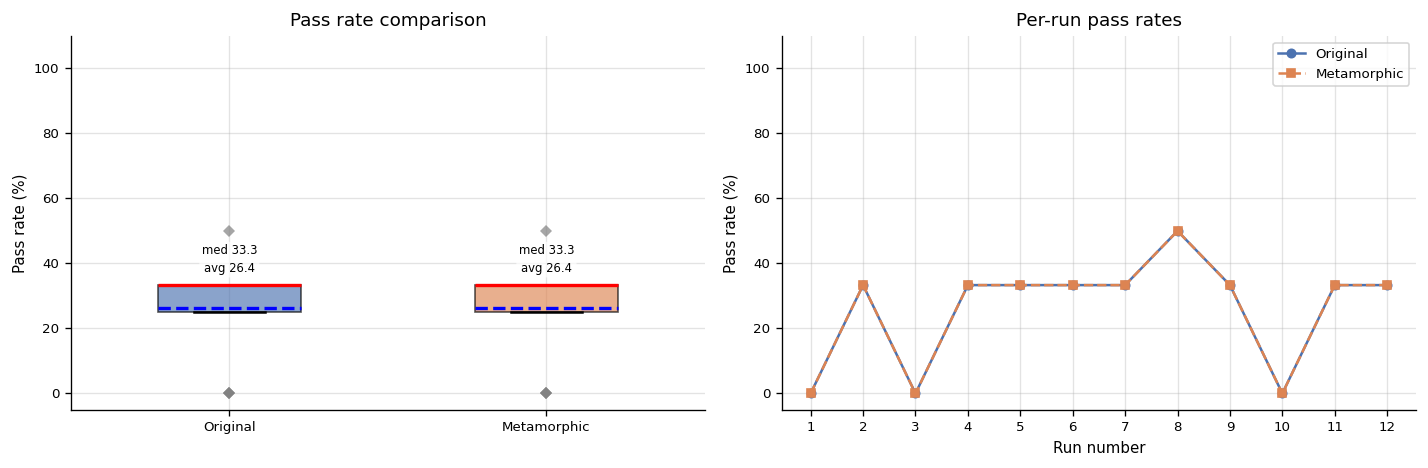

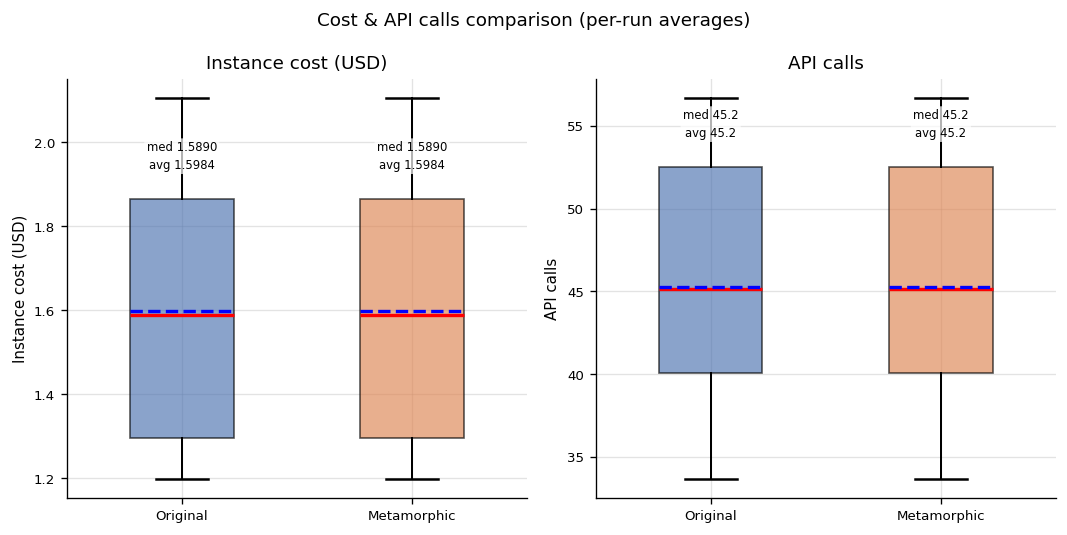

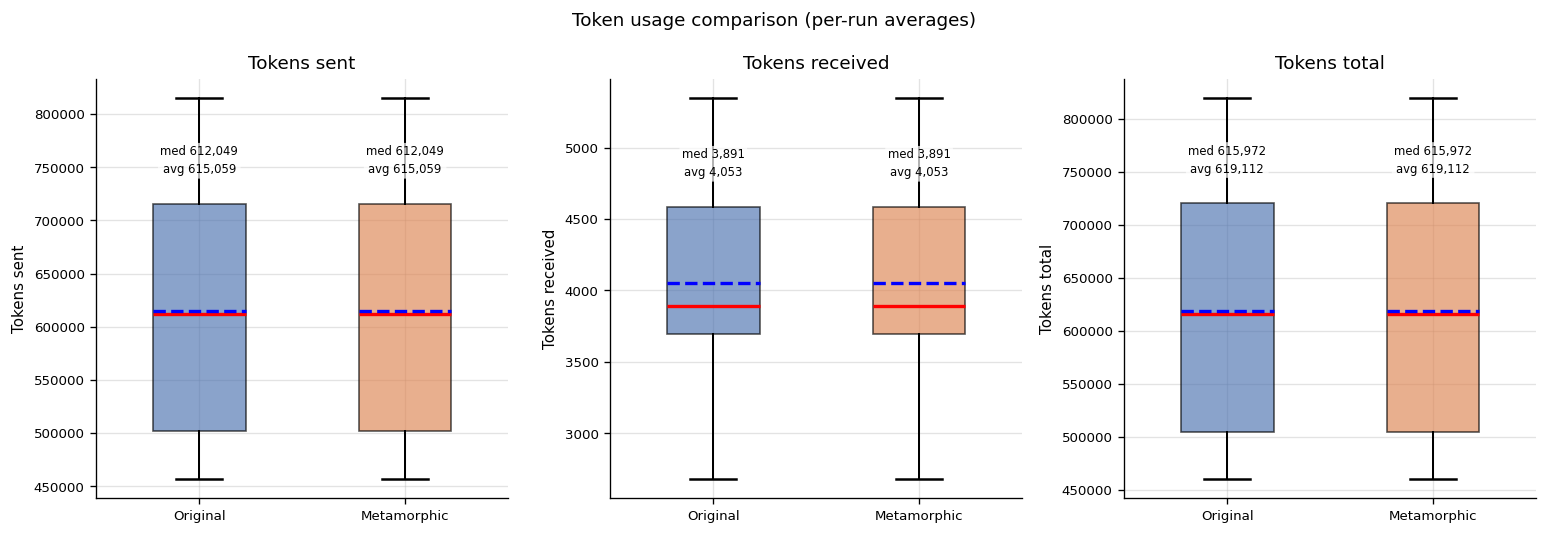

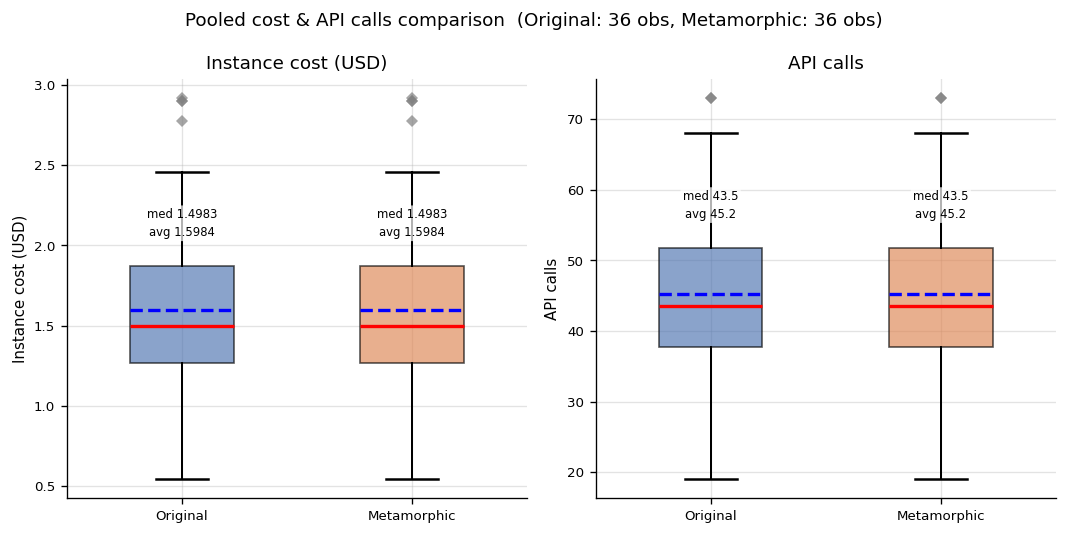

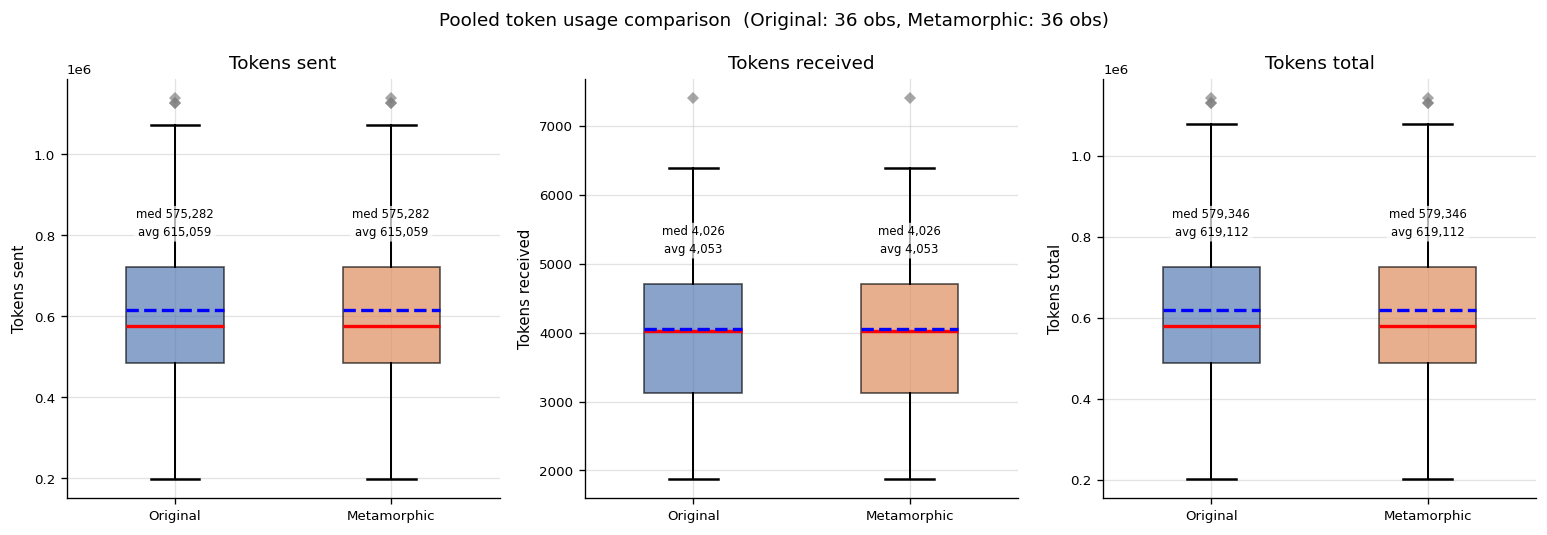


──────────────────────────────────────────────────
  Original  (12 runs × 3 instances)
──────────────────────────────────────────────────
  Pass rate          26.4 %   ± 16.6
  Instance cost    $  1.5984   (median $1.4983)
  Tokens sent         615,059   (median 575,282)
  Tokens received       4,053   (median 4,026)
  Tokens total        619,112
  API calls           45.2   (median 43.5)
──────────────────────────────────────────────────

  Note: M=3 instances/run → pass rate takes only discrete values
  (multiples of 33.3%). The ±std reflects discrete distribution
  spread, not measurement noise.

──────────────────────────────────────────────────
  Metamorphic  (12 runs × 3 instances)
──────────────────────────────────────────────────
  Pass rate          26.4 %   ± 16.6
  Instance cost    $  1.5984   (median $1.4983)
  Tokens sent         615,059   (median 575,282)
  Tokens received       4,053   (median 4,026)
  Tokens total        619,112
  API calls           45.2   (median 43.

In [7]:
# ─── Run ──────────────────────────────────────────────────────────────────────
# Edit EVAL_DIR_A / EVAL_DIR_B / LABEL_A / LABEL_B in cell 1 above, then
# re-run this cell.  Set EVAL_DIR_B = None for a single-eval report.

if EVAL_DIR_B is None:
    build_single_report(EVAL_DIR_A, LABEL_A)
else:
    build_comparison_report(EVAL_DIR_A, LABEL_A, EVAL_DIR_B, LABEL_B)